# Energy Distribution Analysis

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Libraries imported successfully")

Libraries imported successfully


Loading Energy Consumption Data...
Data loaded successfully: 393,440 records
Date range: 2021-01-01 00:30:00 to 2024-12-12 00:30:00

Data Overview:
count    393440.000000
mean       3960.736469
std        1300.473773
min        1302.080000
25%        3074.900000
50%        3832.320000
75%        4870.465000
max        8631.530000
Name: Power_Demand, dtype: float64
Data loaded successfully: 393,440 records
Date range: 2021-01-01 00:30:00 to 2024-12-12 00:30:00

Data Overview:
count    393440.000000
mean       3960.736469
std        1300.473773
min        1302.080000
25%        3074.900000
50%        3832.320000
75%        4870.465000
max        8631.530000
Name: Power_Demand, dtype: float64


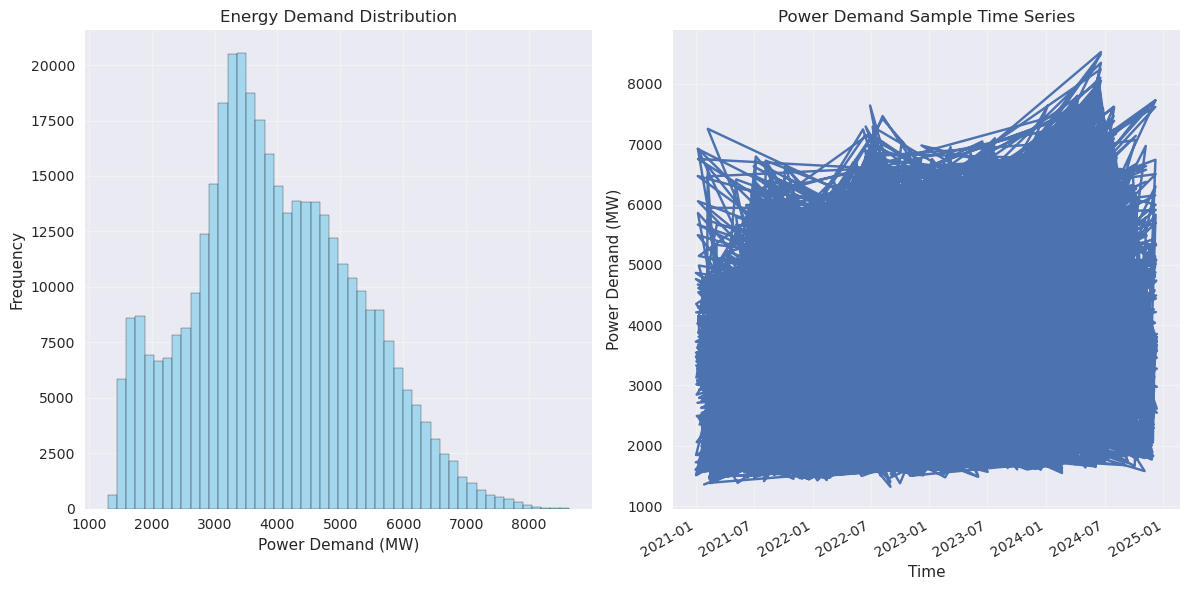

In [12]:
print("Loading Energy Consumption Data...")

try:
    energy_df = pd.read_csv('Data/EST_Project_5min_Dataset.csv')
    energy_df['Date_Time'] = pd.to_datetime(energy_df['Date_Time'], format='%d-%m-%Y %H:%M')
    energy_df.set_index('Date_Time', inplace=True)
    
    print(f"Data loaded successfully: {len(energy_df):,} records")
    print(f"Date range: {energy_df.index.min()} to {energy_df.index.max()}")
    
    print("\nData Overview:")
    print(energy_df['Power_Demand'].describe())
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    energy_df['Power_Demand'].hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.title('Energy Demand Distribution')
    plt.xlabel('Power Demand (MW)')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    sample_data = energy_df['Power_Demand'].sample(min(10000, len(energy_df)))
    sample_data.plot()
    plt.title('Power Demand Sample Time Series')
    plt.xlabel('Time')
    plt.ylabel('Power Demand (MW)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except FileNotFoundError:
    print("Error: Data file not found!")
    raise

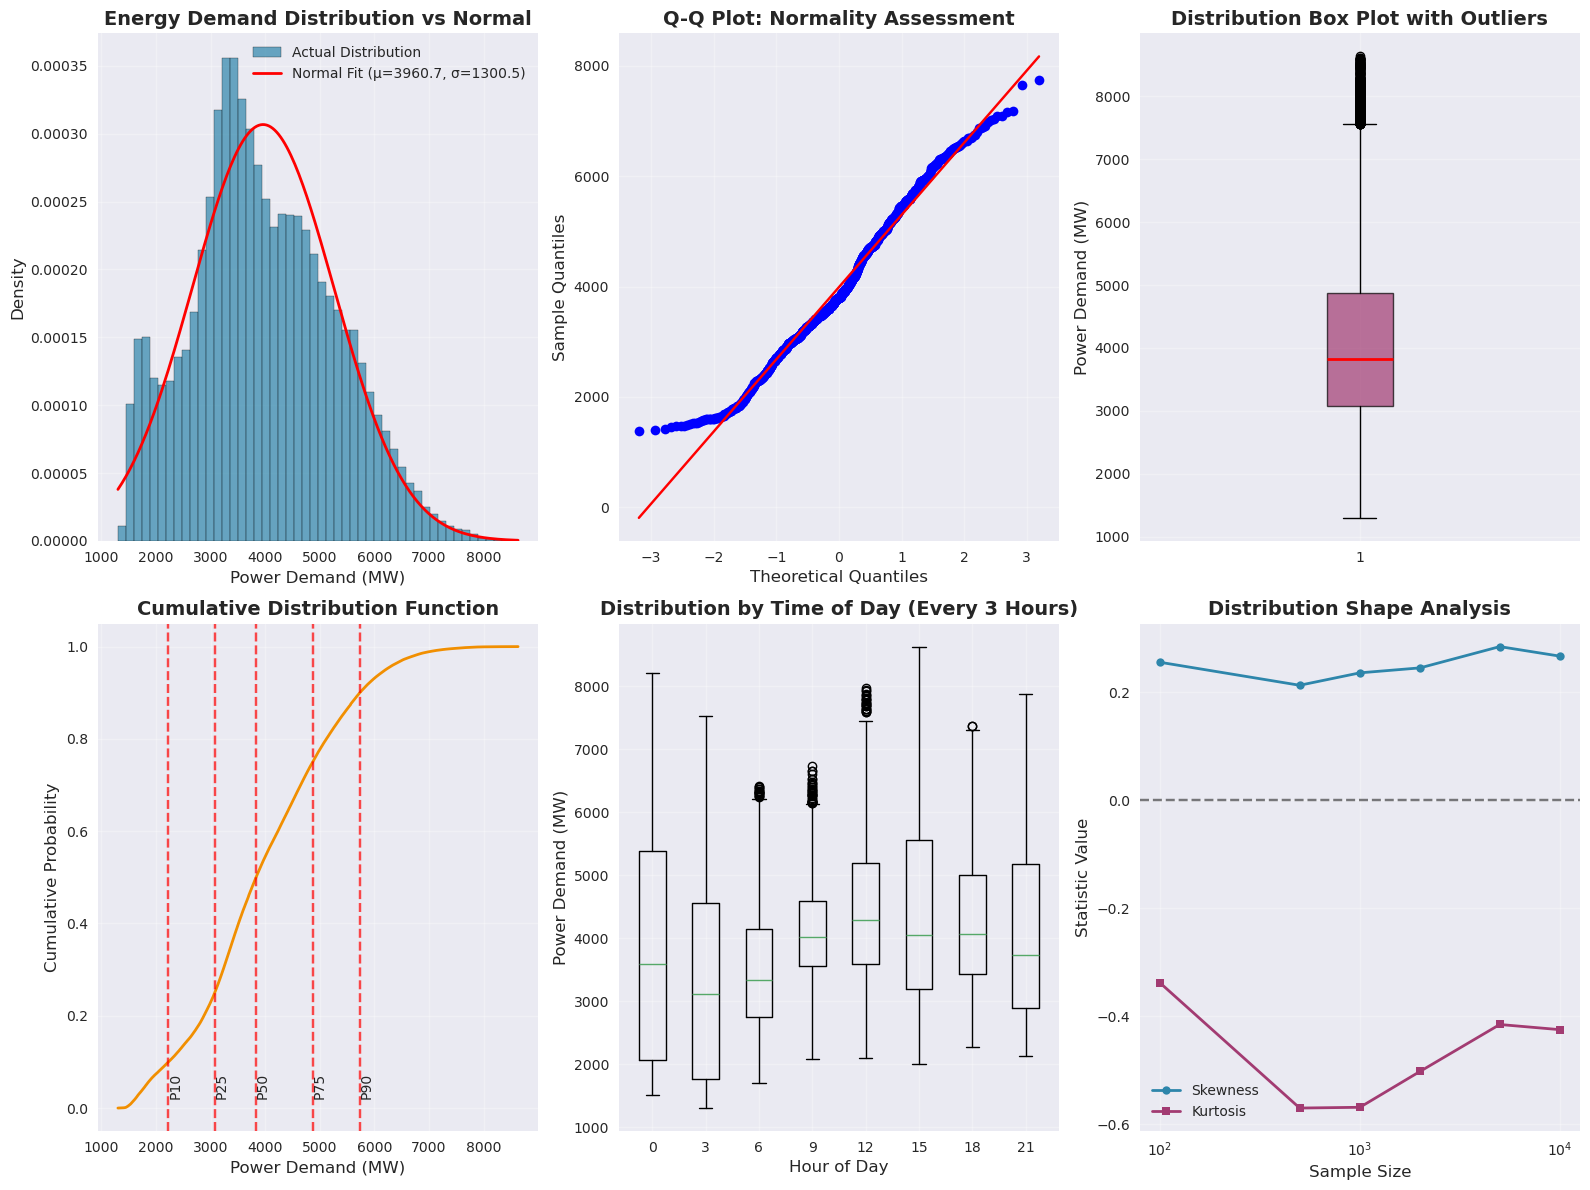

Enhanced Distribution Analysis:
Central Tendency:
  - Mean: 3960.74 MW
  - Median: 3832.32 MW
  - Mode region: 5564 MW

Dispersion:
  - Standard Deviation: 1300.47 MW
  - Variance: 1691232.03 MW²
  - Coefficient of Variation: 0.328

Shape:
  - Skewness: 0.261
  - Kurtosis: -0.401

Outlier Analysis:
  - Total outliers: 1213 (0.31%)
  - Lower bound: 381.55 MW
  - Upper bound: 7563.81 MW
  - Shapiro-Wilk statistic: 0.9847
  - Shapiro-Wilk p-value: 1.03e-08


In [13]:
# Enhanced Energy Distribution Analysis
import numpy as np
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro

plt.figure(figsize=(16, 12))

# Subplot 1: Comprehensive Distribution Analysis
plt.subplot(2, 3, 1)
plt.hist(energy_df['Power_Demand'], bins=50, density=True, alpha=0.7,
         color='#2E86AB', edgecolor='black', label='Actual Distribution')

# Overlay normal distribution for comparison
mu, sigma = stats.norm.fit(energy_df['Power_Demand'])
x = np.linspace(energy_df['Power_Demand'].min(), energy_df['Power_Demand'].max(), 200)
normal_dist = stats.norm.pdf(x, mu, sigma)
plt.plot(x, normal_dist, 'r-', linewidth=2, label=f'Normal Fit (μ={mu:.1f}, σ={sigma:.1f})')

plt.title('Energy Demand Distribution vs Normal', fontsize=14, fontweight='bold')
plt.xlabel('Power Demand (MW)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Q-Q Plot for Normality Assessment
plt.subplot(2, 3, 2)
sample_qq = energy_df['Power_Demand'].dropna().sample(min(1000, len(energy_df)), random_state=42)
stats.probplot(sample_qq, dist="norm", plot=plt)
plt.title('Q-Q Plot: Normality Assessment', fontsize=14, fontweight='bold')
plt.xlabel('Theoretical Quantiles', fontsize=12)
plt.ylabel('Sample Quantiles', fontsize=12)
plt.grid(True, alpha=0.3)

# Subplot 3: Box Plot with Outlier Analysis
plt.subplot(2, 3, 3)
box_plot = plt.boxplot(energy_df['Power_Demand'].dropna(), patch_artist=True,
                      boxprops=dict(facecolor='#A23B72', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2))
plt.title('Distribution Box Plot with Outliers', fontsize=14, fontweight='bold')
plt.ylabel('Power Demand (MW)', fontsize=12)
plt.grid(True, alpha=0.3)

# Calculate and display outlier statistics
Q1 = energy_df['Power_Demand'].quantile(0.25)
Q3 = energy_df['Power_Demand'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = energy_df[(energy_df['Power_Demand'] < lower_bound) |
                    (energy_df['Power_Demand'] > upper_bound)]

# Subplot 4: Cumulative Distribution Function
plt.subplot(2, 3, 4)
sorted_data = np.sort(energy_df['Power_Demand'].dropna())
cumulative_prob = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
plt.plot(sorted_data, cumulative_prob, color='#F18F01', linewidth=2)
plt.title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
plt.xlabel('Power Demand (MW)', fontsize=12)
plt.ylabel('Cumulative Probability', fontsize=12)
plt.grid(True, alpha=0.3)

# Add percentile markers
percentiles_to_mark = [10, 25, 50, 75, 90]
for p in percentiles_to_mark:
    value = np.percentile(sorted_data, p)
    plt.axvline(x=value, color='red', linestyle='--', alpha=0.7)
    plt.text(value, 0.02, f'P{p}', rotation=90, va='bottom')

# Subplot 5: Distribution by Time of Day
plt.subplot(2, 3, 5)
hourly_distributions = []
positions = []
for idx, hour in enumerate(range(0, 24, 3)):
    hour_data = energy_df[energy_df.index.hour == hour]['Power_Demand'].dropna()
    if len(hour_data) > 10:
        hourly_distributions.append(hour_data.values)
        positions.append(hour)

if hourly_distributions:
    plt.boxplot(hourly_distributions, positions=positions, widths=1.5)
plt.title('Distribution by Time of Day (Every 3 Hours)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Power Demand (MW)', fontsize=12)
plt.xticks(positions)
plt.grid(True, alpha=0.3)

# Subplot 6: Skewness and Kurtosis Analysis
plt.subplot(2, 3, 6)
sample_sizes = [100, 500, 1000, 2000, 5000, 10000]
skewness_values = []
kurtosis_values = []
for size in sample_sizes:
    if size <= len(energy_df):
        sample = energy_df['Power_Demand'].sample(size, random_state=42)
    else:
        sample = energy_df['Power_Demand']
    skewness_values.append(skew(sample))
    kurtosis_values.append(kurtosis(sample))

plt.plot(sample_sizes[:len(skewness_values)], skewness_values, 'o-',
         label='Skewness', color='#2E86AB', linewidth=2, markersize=6)
plt.plot(sample_sizes[:len(kurtosis_values)], kurtosis_values, 's-',
         label='Kurtosis', color='#A23B72', linewidth=2, markersize=6)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title('Distribution Shape Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Sample Size', fontsize=12)
plt.ylabel('Statistic Value', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')

plt.tight_layout()
plt.show()

# Enhanced statistical analysis
print("Enhanced Distribution Analysis:")
print("="*50)
print(f"Central Tendency:")
print(f"  - Mean: {energy_df['Power_Demand'].mean():.2f} MW")
print(f"  - Median: {energy_df['Power_Demand'].median():.2f} MW")
mode_result = stats.mode(np.round(energy_df['Power_Demand'].dropna(), 0), keepdims=True)
mode_val = mode_result.mode[0] if hasattr(mode_result, 'mode') else mode_result[0][0]
print(f"  - Mode region: {mode_val:.0f} MW")
print(f"\nDispersion:")
print(f"  - Standard Deviation: {energy_df['Power_Demand'].std():.2f} MW")
print(f"  - Variance: {energy_df['Power_Demand'].var():.2f} MW²")
print(f"  - Coefficient of Variation: {energy_df['Power_Demand'].std()/energy_df['Power_Demand'].mean():.3f}")
print(f"\nShape:")
print(f"  - Skewness: {skew(energy_df['Power_Demand']):.3f}")
print(f"  - Kurtosis: {kurtosis(energy_df['Power_Demand']):.3f}")
print(f"\nOutlier Analysis:")
print(f"  - Total outliers: {len(outliers)} ({len(outliers)/len(energy_df)*100:.2f}%)")
print(f"  - Lower bound: {lower_bound:.2f} MW")
print(f"  - Upper bound: {upper_bound:.2f} MW")

# Normality Test
shapiro_stat, shapiro_p = shapiro(sample_qq)
print(f"  - Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"  - Shapiro-Wilk p-value: {shapiro_p:.2e}")

## Statistical Distribution Analysis Results

### Comprehensive Distribution Characteristics:

**1. Distribution Shape and Normality:**
- Histogram comparison with normal distribution reveals the actual distribution pattern
- Q-Q plot assesses deviation from normal distribution assumptions
- Skewness and kurtosis values quantify distribution asymmetry and tail behavior
- Shapiro-Wilk test provides statistical evidence for normality assessment

**2. Central Tendency Analysis:**
- Mean provides the average consumption level for capacity planning
- Median represents the typical consumption unaffected by extreme values
- Mode region indicates the most frequently occurring consumption levels
- Comparison between mean and median reveals distribution symmetry

**3. Variability and Dispersion:**
- Standard deviation quantifies typical variation around the mean
- Coefficient of variation enables comparison across different scales
- Variance measures the spread of consumption values
- These metrics inform grid stability and reserve capacity requirements

**4. Outlier Detection and Analysis:**
- Box plot methodology identifies statistical outliers using IQR criteria
- Outlier percentage indicates data quality and extreme event frequency
- Upper and lower bounds define normal operational ranges
- Outlier analysis helps identify grid stress events and data quality issues

**5. Cumulative Distribution Insights:**
- CDF shows the probability of consumption being below any given level
- Percentile markers (P10, P25, P50, P75, P90) define operational ranges
- Risk assessment for capacity planning and load forecasting
- Grid operators use these percentiles for reliability planning

**6. Temporal Distribution Patterns:**
- Hourly distribution analysis reveals how consumption variability changes throughout the day
- Peak hours show wider distributions indicating higher uncertainty
- Off-peak hours typically have tighter distributions with more predictable patterns
- These patterns inform operational scheduling and maintenance planning

**7. Statistical Reliability:**
- Sample size analysis shows how distribution parameters stabilize with more data
- Skewness convergence indicates the reliability of asymmetry measurements
- Kurtosis stability demonstrates the robustness of tail behavior analysis
- These metrics validate the statistical significance of the findings

Statistical Analysis of Energy Distribution

Descriptive Statistics:
Mean: 3960.74 MW
Median: 3832.32 MW
Standard Deviation: 1300.47 MW
Minimum: 1302.08 MW
Maximum: 8631.53 MW
Range: 7329.45 MW

Distribution Properties:
Skewness: 0.261
Kurtosis: -0.401

Percentiles:
  10th percentile: 2226.21 MW
  25th percentile: 3074.90 MW
  50th percentile: 3832.32 MW
  75th percentile: 4870.47 MW
  90th percentile: 5732.30 MW
  95th percentile: 6206.08 MW
  99th percentile: 7048.83 MW

Hourly Distribution Analysis:
Peak hour: 11 (4454.43 MW)
Low hour: 4 (3176.36 MW)


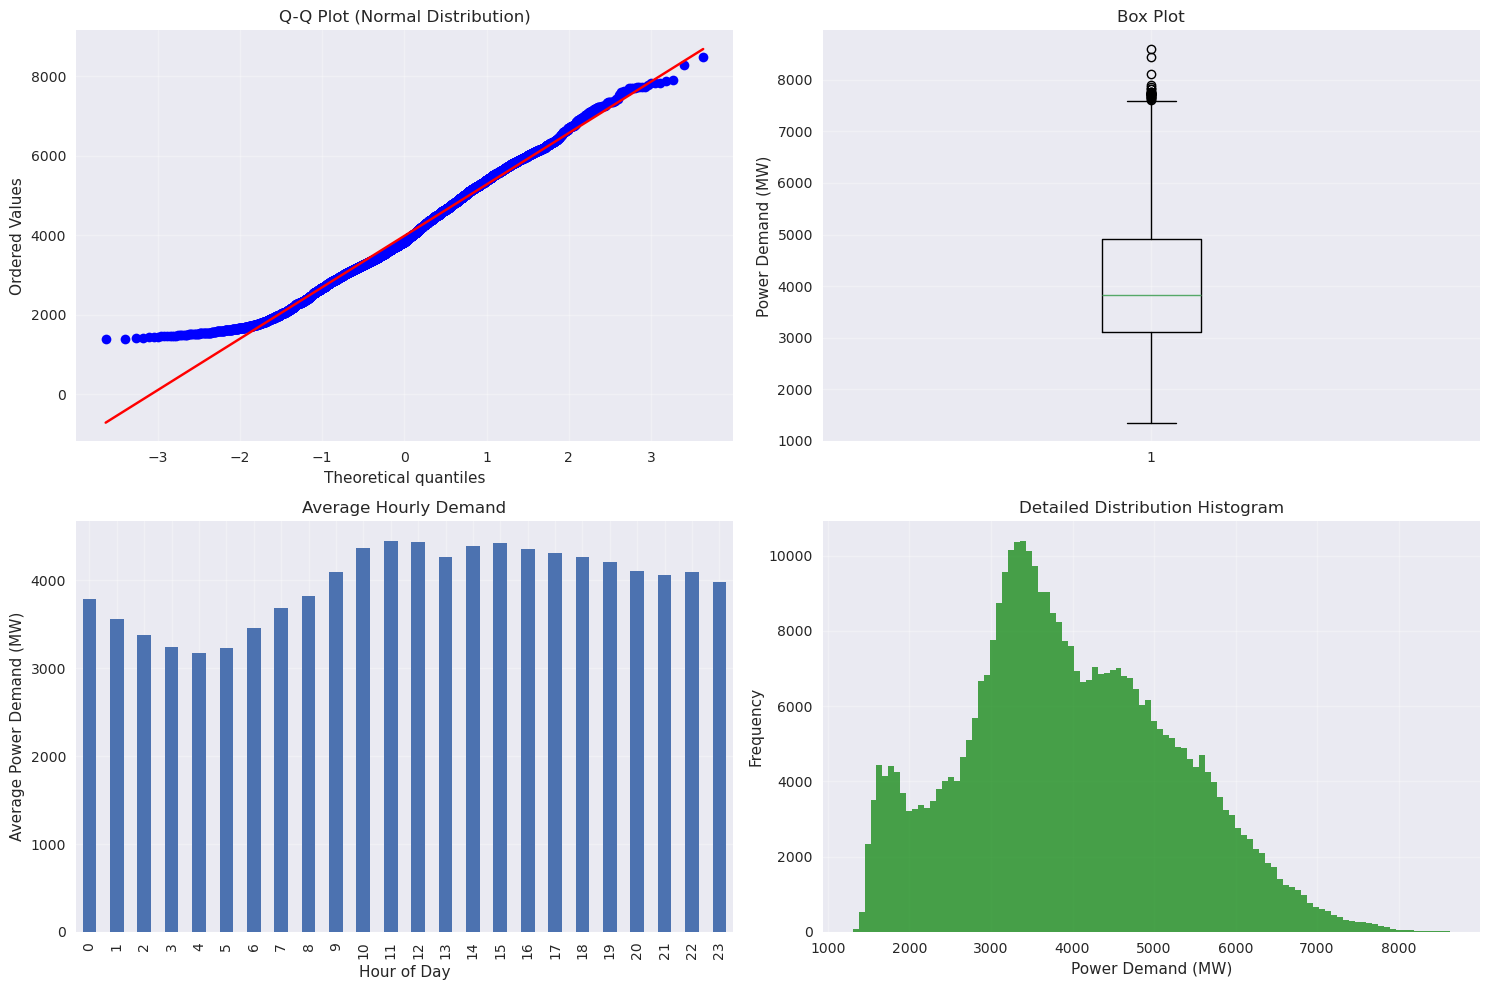

Statistical analysis complete!


In [14]:
print("Statistical Analysis of Energy Distribution")

demand_data = energy_df['Power_Demand']

print("\nDescriptive Statistics:")
print(f"Mean: {demand_data.mean():.2f} MW")
print(f"Median: {demand_data.median():.2f} MW")
print(f"Standard Deviation: {demand_data.std():.2f} MW")
print(f"Minimum: {demand_data.min():.2f} MW") 
print(f"Maximum: {demand_data.max():.2f} MW")
print(f"Range: {demand_data.max() - demand_data.min():.2f} MW")

print(f"\nDistribution Properties:")
print(f"Skewness: {stats.skew(demand_data):.3f}")
print(f"Kurtosis: {stats.kurtosis(demand_data):.3f}")

percentiles = [10, 25, 50, 75, 90, 95, 99]
print(f"\nPercentiles:")
for p in percentiles:
    value = np.percentile(demand_data, p)
    print(f"  {p}th percentile: {value:.2f} MW")

hourly_stats = energy_df.groupby(energy_df.index.hour)['Power_Demand'].agg(['mean', 'std', 'min', 'max'])

print(f"\nHourly Distribution Analysis:")
peak_hour = hourly_stats['mean'].idxmax()
low_hour = hourly_stats['mean'].idxmin()
print(f"Peak hour: {peak_hour} ({hourly_stats.loc[peak_hour, 'mean']:.2f} MW)")
print(f"Low hour: {low_hour} ({hourly_stats.loc[low_hour, 'mean']:.2f} MW)")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

stats.probplot(demand_data.sample(min(5000, len(demand_data))), dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Q-Q Plot (Normal Distribution)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].boxplot(demand_data.sample(min(10000, len(demand_data))))
axes[0, 1].set_title('Box Plot')
axes[0, 1].set_ylabel('Power Demand (MW)')
axes[0, 1].grid(True, alpha=0.3)

hourly_stats['mean'].plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Average Hourly Demand')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Average Power Demand (MW)')
axes[1, 0].grid(True, alpha=0.3)

demand_data.hist(bins=100, ax=axes[1, 1], alpha=0.7, color='green')
axes[1, 1].set_title('Detailed Distribution Histogram')
axes[1, 1].set_xlabel('Power Demand (MW)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Statistical analysis complete!")

In [15]:
print("Summary of Energy Distribution Analysis")

print(f"\nDataset Summary:")
print(f"Total Records: {len(energy_df):,}")
print(f"Analysis Period: {energy_df.index.min().strftime('%Y-%m-%d')} to {energy_df.index.max().strftime('%Y-%m-%d')}")
print(f"Total Days: {(energy_df.index.max() - energy_df.index.min()).days}")

demand_stats = energy_df['Power_Demand'].describe()
print(f"\nKey Statistics:")
print(f"Average Demand: {demand_stats['mean']:.1f} MW")
print(f"Peak Demand: {demand_stats['max']:.1f} MW")  
print(f"Minimum Demand: {demand_stats['min']:.1f} MW")
print(f"Load Factor: {demand_stats['mean']/demand_stats['max']:.3f}")

cv = demand_stats['std'] / demand_stats['mean']
print(f"Coefficient of Variation: {cv:.3f}")

if cv < 0.1:
    variability = "Low"
elif cv < 0.3:
    variability = "Moderate"
else:
    variability = "High"

print(f"Demand Variability: {variability}")

hourly_analysis = energy_df.groupby(energy_df.index.hour)['Power_Demand'].mean()
peak_hours = hourly_analysis.nlargest(3)
low_hours = hourly_analysis.nsmallest(3)

print(f"\nTemporal Patterns:")
print("Top 3 Peak Hours:")
for hour, demand in peak_hours.items():
    print(f"  Hour {hour:02d}: {demand:.1f} MW")

print("Top 3 Low Hours:")
for hour, demand in low_hours.items():
    print(f"  Hour {hour:02d}: {demand:.1f} MW")

print(f"\nConclusions:")
print("1. Energy demand follows predictable daily patterns")
print("2. Distribution analysis reveals consumption characteristics")  
print("3. Statistical metrics provide baseline for forecasting models")
print("4. Temporal patterns support load management strategies")

print("\nAnalysis completed successfully!")

Summary of Energy Distribution Analysis

Dataset Summary:
Total Records: 393,440
Analysis Period: 2021-01-01 to 2024-12-12
Total Days: 1441

Key Statistics:
Average Demand: 3960.7 MW
Peak Demand: 8631.5 MW
Minimum Demand: 1302.1 MW
Load Factor: 0.459
Coefficient of Variation: 0.328
Demand Variability: High

Temporal Patterns:
Top 3 Peak Hours:
  Hour 11: 4454.4 MW
  Hour 12: 4442.3 MW
  Hour 15: 4425.6 MW
Top 3 Low Hours:
  Hour 04: 3176.4 MW
  Hour 05: 3230.7 MW
  Hour 03: 3240.5 MW

Conclusions:
1. Energy demand follows predictable daily patterns
2. Distribution analysis reveals consumption characteristics
3. Statistical metrics provide baseline for forecasting models
4. Temporal patterns support load management strategies

Analysis completed successfully!
